# ViT-B-16 Analysis Try 2

This notebook follows the same structure as `efficentnet_history_plots.ipynb`:
1. Plot training history (`accuracy/loss vs epoch`) from JSON files.
2. Run variant failure analysis with trade-off visualizations and Grad-CAM.


In [15]:
# History plots from JSON
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
if (BASE_DIR / 'history_linear.json').exists():
    CKPT_DIR = BASE_DIR
elif (BASE_DIR / 'Vision Transformer' / 'history_linear.json').exists():
    CKPT_DIR = BASE_DIR / 'Vision Transformer'
else:
    raise FileNotFoundError('Could not find ViT history JSON files from current working directory.')

history_files = {
    'linear_probe': CKPT_DIR / 'history_linear.json',
    'batchnorm_tuning': CKPT_DIR / 'history_bn.json',
    'adapter_tuning': CKPT_DIR / 'history_adapter.json',
    'lora_tuning': CKPT_DIR / 'history_lora.json',
    'full_finetune': CKPT_DIR / 'history_full.json',
}

histories = {}
for name, path in history_files.items():
    if not path.exists():
        print(f'[WARN] Missing history file for {name}: {path}')
        continue
    with open(path, 'r') as f:
        histories[name] = json.load(f)

if not histories:
    raise RuntimeError('No history JSON files were loaded.')

print('Loaded histories from:', CKPT_DIR)
for k, h in histories.items():
    print(f"{k:>16}: epochs={len(h.get('val_acc', []))}, keys={sorted(h.keys())}")


Loaded histories from: /content
    linear_probe: epochs=9, keys=['epoch_time', 'total_time', 'train_loss', 'val_acc', 'val_loss']
batchnorm_tuning: epochs=8, keys=['epoch_time', 'total_time', 'train_loss', 'val_acc', 'val_loss']
  adapter_tuning: epochs=4, keys=['epoch_time', 'total_time', 'train_loss', 'val_acc', 'val_loss']
     lora_tuning: epochs=30, keys=['epoch_time', 'total_time', 'train_loss', 'val_acc', 'val_loss']
   full_finetune: epochs=9, keys=['epoch_time', 'total_time', 'train_loss', 'val_acc', 'val_loss']


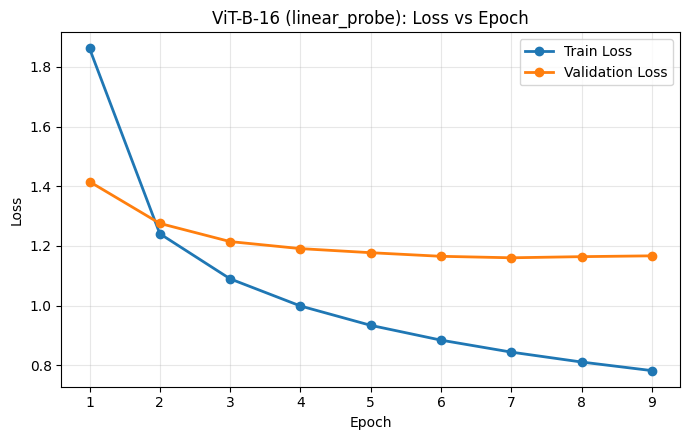

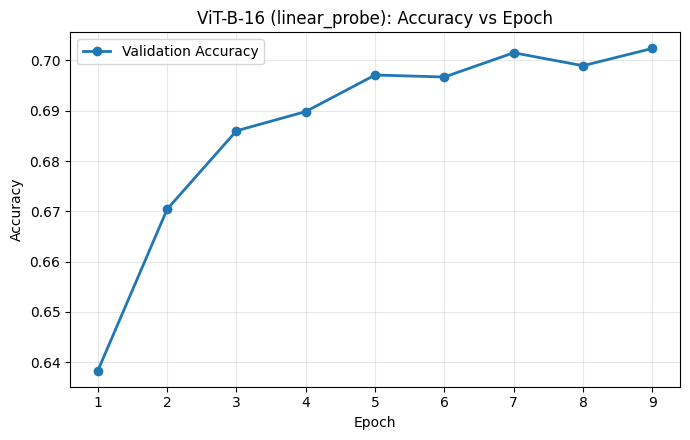

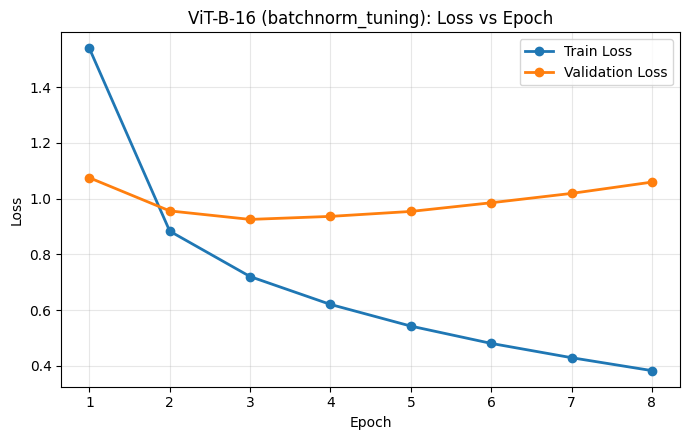

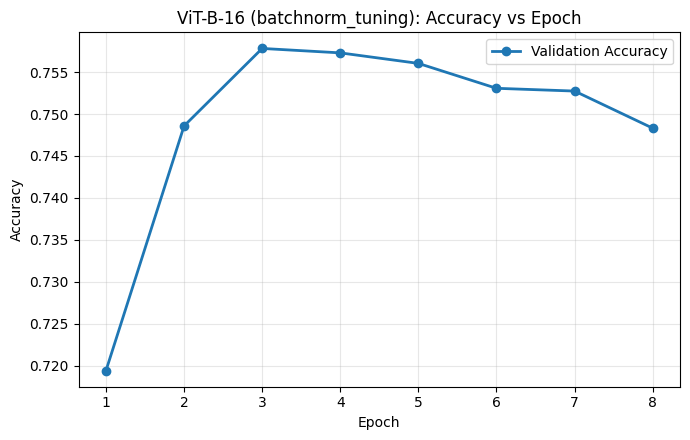

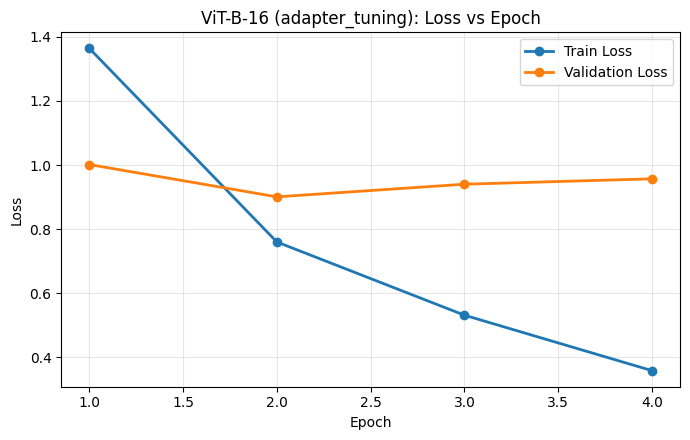

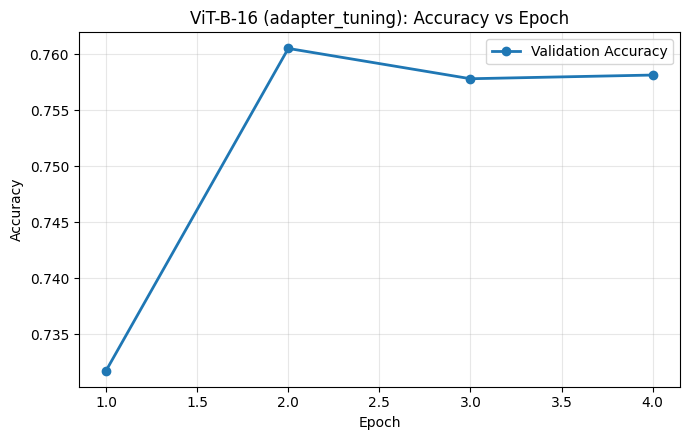

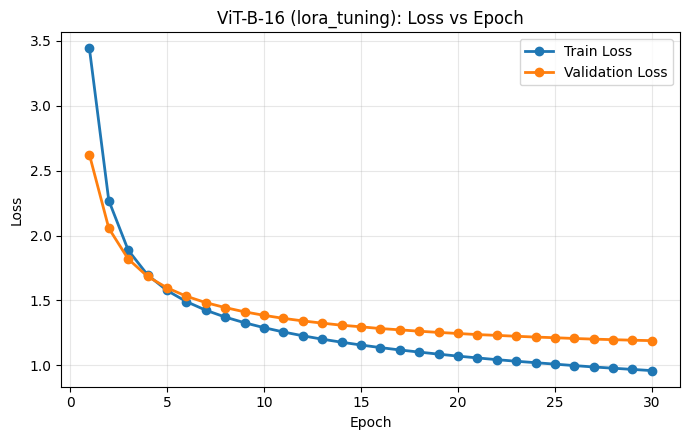

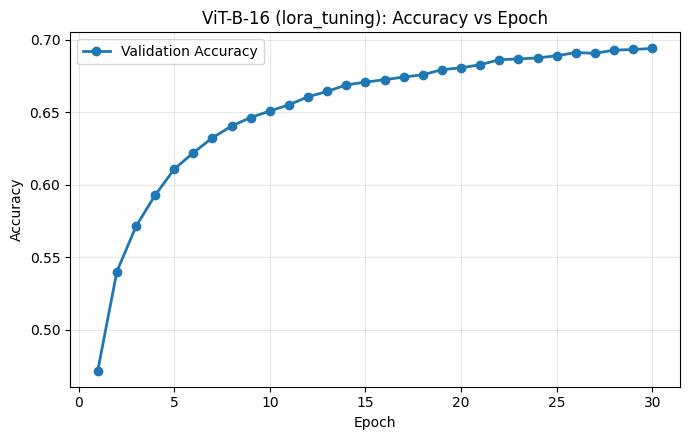

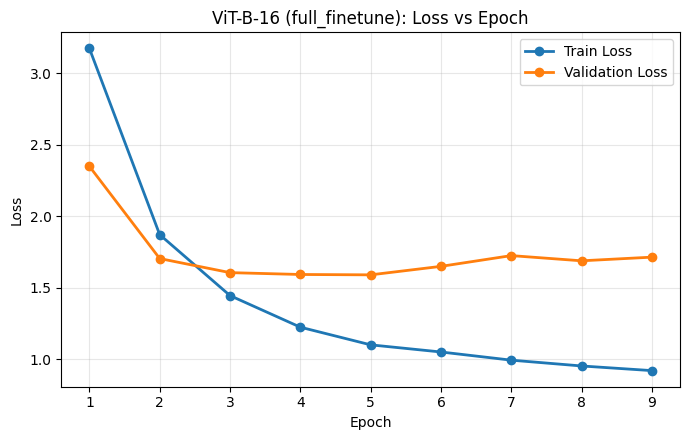

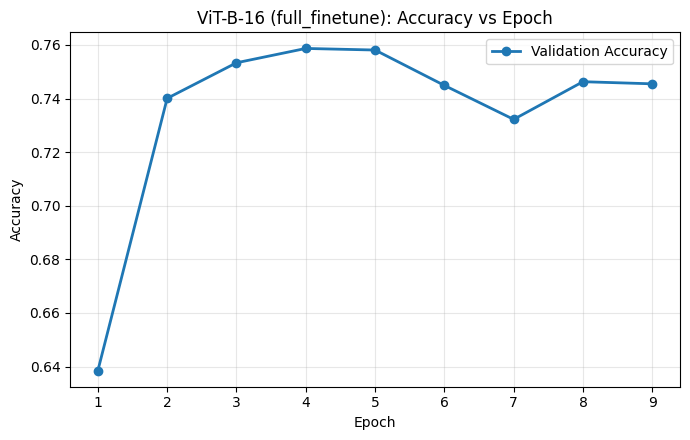

Saved per-strategy history curves to: /content


In [16]:
# Per-strategy accuracy/loss vs epoch
for strategy, hist in histories.items():
    train_loss = hist.get('train_loss', [])
    val_loss = hist.get('val_loss', [])
    val_acc = hist.get('val_acc', [])

    x_loss = np.arange(1, len(train_loss) + 1)
    x_acc = np.arange(1, len(val_acc) + 1)

    plt.figure(figsize=(7, 4.5))
    if len(train_loss):
        plt.plot(x_loss, train_loss, marker='o', linewidth=2, label='Train Loss')
    if len(val_loss):
        plt.plot(x_loss, val_loss, marker='o', linewidth=2, label='Validation Loss')
    plt.title(f'ViT-B-16 ({strategy}): Loss vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    loss_out = CKPT_DIR / f'loss_curve_{strategy}_vit.png'
    plt.savefig(loss_out, dpi=220)
    plt.show()

    plt.figure(figsize=(7, 4.5))
    if len(val_acc):
        plt.plot(x_acc, val_acc, marker='o', linewidth=2, label='Validation Accuracy')
    plt.title(f'ViT-B-16 ({strategy}): Accuracy vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    acc_out = CKPT_DIR / f'accuracy_curve_{strategy}_vit.png'
    plt.savefig(acc_out, dpi=220)
    plt.show()

print('Saved per-strategy history curves to:', CKPT_DIR)


## Variant Failure Analysis

This section follows the same structure as the EfficientNet notebook:
1. Setup paths/imports/models.
2. Download/discover transformed test variants.
3. Evaluate strategies on variants and clean test.
4. Plot trade-offs (time/FLOPs/inference speed vs performance).
5. Generate Grad-CAM failure comparison.


In [17]:
# Core imports and project paths
import gc
import math
import time
import tarfile
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets
from torchvision.models import vit_b_16, ViT_B_16_Weights

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'history_linear.json').exists():
    alt = PROJECT_DIR / 'Vision Transformer'
    if (alt / 'history_linear.json').exists():
        PROJECT_DIR = alt

print('PROJECT_DIR:', PROJECT_DIR)

history_files = {
    'linear_probe': PROJECT_DIR / 'history_linear.json',
    'batchnorm_tuning': PROJECT_DIR / 'history_bn.json',
    'adapter_tuning': PROJECT_DIR / 'history_adapter.json',
    'lora_tuning': PROJECT_DIR / 'history_lora.json',
    'full_finetune': PROJECT_DIR / 'history_full.json',
}

# --- Robust checkpoint discovery (supports local + Colab + Combined_Models naming) ---
search_dirs = []
for d in [
    PROJECT_DIR,
    PROJECT_DIR.parent / 'Vision Transformer',
    PROJECT_DIR.parent / 'Combined_Models',
    PROJECT_DIR.parent,
    Path('/content/drive/MyDrive/Combined_Models'),
    Path('/content/drive/MyDrive/Vision Transformer'),
    Path('/content/drive/MyDrive'),
]:
    if d not in search_dirs:
        search_dirs.append(d)

# Try both old and new naming conventions.
ckpt_name_candidates = {
    'linear_probe': [
        'best_linear_model_vit.pth',
        'linear_model_vit.pth',
    ],
    'batchnorm_tuning': [
        'batch_norm_model.pth',
        'batch_norm_model_vit.pth',
    ],
    'adapter_tuning': [
        'adapter_model.pth',
        'adapter_model_vit.pth',
    ],
    'lora_tuning': [
        'lora_model.pth',
        'lora_model_vit.pth',
    ],
    'full_finetune': [
        'full_model.pth',
        'full_model_vit.pth',
    ],
}


def first_existing_file(candidates):
    for c in candidates:
        if c.exists():
            return c
    return None


strategy_ckpts = {}
for strategy, names in ckpt_name_candidates.items():
    candidates = []
    for root in search_dirs:
        for name in names:
            candidates.append(root / name)
    found = first_existing_file(candidates)
    strategy_ckpts[strategy] = found

missing_ckpts = [s for s, pth in strategy_ckpts.items() if pth is None]
if missing_ckpts:
    print('[WARN] Missing checkpoints for:', missing_ckpts)

print('Checkpoint map:')
for s, pth in strategy_ckpts.items():
    print(f"- {s}: {pth}")

STRATEGIES = [s for s, pth in strategy_ckpts.items() if pth is not None]
if not STRATEGIES:
    print('[WARN] No checkpoints found in search directories.')

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Device:', device)
print('Active strategies:', STRATEGIES)



PROJECT_DIR: /content
[WARN] Missing checkpoints for: ['batchnorm_tuning', 'adapter_tuning']
Checkpoint map:
- linear_probe: /content/linear_model_vit.pth
- batchnorm_tuning: None
- adapter_tuning: None
- lora_tuning: /content/lora_model_vit.pth
- full_finetune: /content/full_model_vit.pth
Device: cuda
Active strategies: ['linear_probe', 'lora_tuning', 'full_finetune']


In [18]:
# Data/model definitions
weights = ViT_B_16_Weights.IMAGENET1K_V1
transform = weights.transforms()


def is_food101_root(p: Path) -> bool:
    return (p / 'images').is_dir() and (p / 'meta' / 'train.txt').is_file() and (p / 'meta' / 'test.txt').is_file()


def find_food101_root() -> Path:
    candidates = [
        PROJECT_DIR / 'food-101' / 'food-101',
        PROJECT_DIR / 'food-101',
        PROJECT_DIR.parent / 'food-101' / 'food-101',
        PROJECT_DIR.parent / 'food-101',
        Path.cwd() / 'food-101' / 'food-101',
        Path.cwd() / 'food-101',
        Path('/Users/jordankaseram/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101'),
    ]

    for c in candidates:
        if is_food101_root(c):
            return c

    try:
        import kagglehub
        kpath = Path(kagglehub.dataset_download('dansbecker/food-101'))
        for c in [kpath / 'food-101' / 'food-101', kpath / 'food-101', kpath]:
            if is_food101_root(c):
                return c
    except Exception as e:
        print('kagglehub fallback not available:', e)

    raise FileNotFoundError('Could not find Food-101 root directory.')


class Food101Dataset(Dataset):
    def __init__(self, root, split_file, transform=None, class_to_idx=None):
        self.root = Path(root)
        self.transform = transform
        with open(split_file, 'r', encoding='utf-8') as f:
            self.samples = [x.strip() for x in f if x.strip()]

        if class_to_idx is None:
            classes = sorted({x.split('/')[0] for x in self.samples})
            self.class_to_idx = {c: i for i, c in enumerate(classes)}
        else:
            self.class_to_idx = dict(class_to_idx)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        cls = item.split('/')[0]
        img = Image.open(self.root / 'images' / f'{item}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.class_to_idx[cls]


class ImageFolderRemapped(Dataset):
    def __init__(self, root, transform, class_to_idx_ref):
        self.base = datasets.ImageFolder(str(root), transform=transform)
        self.index_map = {
            bi: class_to_idx_ref[c]
            for c, bi in self.base.class_to_idx.items()
            if c in class_to_idx_ref
        }

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, y = self.base[idx]
        return img, self.index_map[y]


DATA_ROOT = find_food101_root()
print('DATA_ROOT:', DATA_ROOT)

train_ref = Food101Dataset(DATA_ROOT, DATA_ROOT / 'meta' / 'train.txt', transform=transform)
test_ds = Food101Dataset(DATA_ROOT, DATA_ROOT / 'meta' / 'test.txt', transform=transform, class_to_idx=train_ref.class_to_idx)

BATCH_SIZE_INFER = 64 if device.type == 'cuda' else 16
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_INFER, shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'))

num_classes = len(train_ref.class_to_idx)
class_to_idx_ref = train_ref.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx_ref.items()}


class Adapter(nn.Module):
    def __init__(self, dim, reduction=16):
        super().__init__()
        self.down = nn.Linear(dim, dim // reduction)
        self.up = nn.Linear(dim // reduction, dim)

    def forward(self, x):
        return x + self.up(torch.relu(self.down(x)))


class ViTWithAdapter(nn.Module):
    def __init__(self, model, num_classes=101):
        super().__init__()
        self.model = model
        in_features = model.heads.head.in_features
        self.adapter = Adapter(in_features)
        self.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.model._process_input(x)
        n = x.shape[0]
        cls_token = self.model.class_token.expand(n, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = self.model.encoder(x)
        x = x[:, 0]
        x = self.adapter(x)
        return self.head(x)


class LoRALinear(nn.Module):
    def __init__(self, linear, r=8, alpha=1.0):
        super().__init__()
        self.linear = linear
        self.A = nn.Linear(linear.in_features, r, bias=False)
        self.B = nn.Linear(r, linear.out_features, bias=False)
        self.scaling = alpha / r
        for p in self.linear.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.linear(x) + self.B(self.A(x)) * self.scaling


def apply_lora(model, r=8):
    for name, module in list(model.named_modules()):
        is_mlp_fc1 = 'mlp' in name and ('fc1' in name or name.endswith('.0'))
        if is_mlp_fc1 and isinstance(module, nn.Linear):
            parent = model
            *path, last = name.split('.')
            for p in path:
                parent = getattr(parent, p)
            setattr(parent, last, LoRALinear(module, r=r))


def create_base_vit(num_classes=101):
    model = vit_b_16(weights=None)
    in_dim = model.heads.head.in_features
    model.heads.head = nn.Linear(in_dim, num_classes)
    return model


def build_model_for_strategy_without_weights(strategy):
    if strategy == 'adapter_tuning':
        base = vit_b_16(weights=None)
        model = ViTWithAdapter(base, num_classes=num_classes)
    else:
        model = create_base_vit(num_classes=num_classes)
        if strategy == 'lora_tuning':
            apply_lora(model, r=8)
    return model


def load_strategy_model(strategy):
    state_dict = torch.load(strategy_ckpts[strategy], map_location='cpu')

    if strategy == 'adapter_tuning':
        base = vit_b_16(weights=None)
        model = ViTWithAdapter(base, num_classes=num_classes)
    else:
        model = create_base_vit(num_classes=num_classes)
        if strategy == 'lora_tuning':
            has_lora = any(k.endswith('.A.weight') or k.endswith('.B.weight') for k in state_dict.keys())
            if has_lora:
                apply_lora(model, r=8)

    model.load_state_dict(state_dict, strict=True)
    return model.to(device).eval()


def mark_trainable_like_training(strategy, model):
    if strategy == 'full_finetune':
        for p in model.parameters():
            p.requires_grad = True
        return

    for p in model.parameters():
        p.requires_grad = False

    if strategy in {'linear_probe', 'batchnorm_tuning', 'lora_tuning'}:
        for p in model.heads.parameters():
            p.requires_grad = True

    if strategy == 'batchnorm_tuning':
        for m in model.modules():
            if isinstance(m, nn.LayerNorm):
                if m.weight is not None:
                    m.weight.requires_grad = True
                if m.bias is not None:
                    m.bias.requires_grad = True
    elif strategy == 'adapter_tuning':
        for p in model.adapter.parameters():
            p.requires_grad = True
        for p in model.head.parameters():
            p.requires_grad = True
    elif strategy == 'lora_tuning':
        for m in model.modules():
            if isinstance(m, LoRALinear):
                for p in m.parameters():
                    p.requires_grad = True


def count_trainable_params_for_strategy(strategy):
    m = build_model_for_strategy_without_weights(strategy)
    mark_trainable_like_training(strategy, m)
    n = int(sum(p.numel() for p in m.parameters() if p.requires_grad))
    del m
    return n


def sync_device():
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps' and hasattr(torch, 'mps') and hasattr(torch.mps, 'synchronize'):
        torch.mps.synchronize()


def measure_inference_ips(model, loader, warmup=5, max_batches=30):
    model.eval()
    with torch.no_grad():
        i = 0
        for imgs, _ in loader:
            _ = model(imgs.to(device))
            i += 1
            if i >= warmup:
                break
        sync_device()

        seen = 0
        t0 = time.time()
        i = 0
        for imgs, _ in loader:
            _ = model(imgs.to(device))
            seen += imgs.size(0)
            i += 1
            if i >= max_batches:
                break
        sync_device()

    return seen / max(time.time() - t0, 1e-9)


Using Colab cache for faster access to the 'food-101' dataset.
DATA_ROOT: /kaggle/input/food-101/food-101/food-101


In [19]:
# Variant dataset download/discovery
USE_GOOGLEDRIVE_VARIANTS = False
GOOGLEDRIVE_FILE_ID = '1MvkUSd2ESqBzXgObUYBBxOH6kMFLDP5B'
VARIANT_ARCHIVE_NAME = 'food101_test_variants.zip'

# Colab/local paths
LOCAL_VARIANT_ZIP = Path('/content/drive/MyDrive/food101_test_variants.zip')  # change if in subfolder
VARIANT_DOWNLOAD_DIR = Path('/content/food101_transformed_test_variants')
EXTRACT_DIR = VARIANT_DOWNLOAD_DIR / 'extracted'


def maybe_download_variant_archive(output_dir, file_id, archive_name):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    archive_path = output_dir / archive_name

    if archive_path.exists() and archive_path.stat().st_size > 0:
        print('Using existing archive:', archive_path)
        return archive_path

    try:
        import gdown
    except ImportError as exc:
        raise RuntimeError('Install gdown first: pip install gdown') from exc

    print('Downloading transformed test variants from Google Drive...')
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url=url, output=str(archive_path), quiet=False)

    if not archive_path.exists() or archive_path.stat().st_size == 0:
        raise RuntimeError('Download failed: archive not found or empty.')

    return archive_path


def extract_archive(archive_path, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    suffixes = [s.lower() for s in archive_path.suffixes]
    if archive_path.suffix.lower() == '.zip':
        with zipfile.ZipFile(archive_path, 'r') as zf:
            zf.extractall(output_dir)
    elif '.tar' in suffixes or suffixes[-2:] in [['.tar', '.gz'], ['.tar', '.bz2'], ['.tar', '.xz']]:
        with tarfile.open(archive_path, 'r:*') as tf:
            tf.extractall(output_dir)
    else:
        raise ValueError(f'Unsupported archive type: {archive_path}')


def _contains_class_folders(path):
    if not path.is_dir():
        return False

    class_dirs = [d for d in path.iterdir() if d.is_dir()]
    if not class_dirs:
        return False

    exts = {'.jpg', '.jpeg', '.png', '.webp'}
    hits = 0
    for class_dir in class_dirs[:8]:
        for f in class_dir.iterdir():
            if f.is_file() and f.suffix.lower() in exts:
                hits += 1
                break

    return hits >= max(1, min(3, len(class_dirs)))


def discover_variant_sets(root):
    root = Path(root)
    variants = {}

    if not root.exists():
        return variants

    if _contains_class_folders(root):
        variants[root.name] = root
        return variants

    for child in sorted(root.iterdir()):
        if child.is_dir() and _contains_class_folders(child):
            variants[child.name] = child

    if variants:
        return variants

    for child in sorted(root.iterdir()):
        if not child.is_dir():
            continue
        for grandchild in sorted(child.iterdir()):
            if grandchild.is_dir() and _contains_class_folders(grandchild):
                variants[grandchild.name] = grandchild

    return variants


if USE_GOOGLEDRIVE_VARIANTS:
    archive_path = maybe_download_variant_archive(VARIANT_DOWNLOAD_DIR, GOOGLEDRIVE_FILE_ID, VARIANT_ARCHIVE_NAME)
    if not EXTRACT_DIR.exists() or not any(EXTRACT_DIR.iterdir()):
        print('Extracting downloaded archive...')
        extract_archive(archive_path, EXTRACT_DIR)
    else:
        print('Using existing extracted folder:', EXTRACT_DIR)
else:
    # Local zip workflow (Colab Drive)
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        print('Not running in Colab (or drive already mounted); skipping drive.mount().')

    if not LOCAL_VARIANT_ZIP.exists():
        raise FileNotFoundError(f'Zip not found: {LOCAL_VARIANT_ZIP}')

    if not EXTRACT_DIR.exists() or not any(EXTRACT_DIR.iterdir()):
        print('Extracting local zip...')
        extract_archive(LOCAL_VARIANT_ZIP, EXTRACT_DIR)
    else:
        print('Using existing extracted folder:', EXTRACT_DIR)

variant_sets = discover_variant_sets(EXTRACT_DIR)
if not variant_sets:
    raise RuntimeError('Could not discover variant folders after extraction.')

print('Discovered variant sets:', sorted(variant_sets.keys()))



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using existing extracted folder: /content/food101_transformed_test_variants/extracted
Discovered variant sets: ['blur_little', 'blur_medium', 'clean', 'downsampled', 'masked', 'noise_rotation']


In [20]:
# Variant + clean evaluation and summary table
RUN_SINGLE_STRATEGY = None
MAX_EVAL_SAMPLES_PER_VARIANT = 2000  # set None for full run
BATCH_SIZE = 64 if device.type == 'cuda' else 16
criterion_eval = nn.CrossEntropyLoss(reduction='sum')

if not STRATEGIES:
    raise RuntimeError('No strategy checkpoints found. Update CKPT_DIR/strategy_ckpts first.')

if RUN_SINGLE_STRATEGY is None:
    ACTIVE_STRATEGIES = list(STRATEGIES)
else:
    if RUN_SINGLE_STRATEGY not in STRATEGIES:
        raise ValueError(f'Unknown strategy: {RUN_SINGLE_STRATEGY}. Available: {STRATEGIES}')
    ACTIVE_STRATEGIES = [RUN_SINGLE_STRATEGY]

print('Running strategies:', ACTIVE_STRATEGIES)


def evaluate_loader(model, loader):
    loss_sum = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss_sum += criterion_eval(logits, y).item()
            y_true.extend(y.cpu().tolist())
            y_pred.extend(logits.argmax(1).cpu().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = float((y_pred == y_true).mean()) if len(y_true) else 0.0
    avg_loss = float(loss_sum / max(len(y_true), 1))
    return {'acc': acc, 'loss': avg_loss, 'y_true': y_true, 'y_pred': y_pred}


strategy_trainable_params = {s: count_trainable_params_for_strategy(s) for s in ACTIVE_STRATEGIES}

rows = []
pred_store = {}
true_store = {}
variant_datasets = {}
failed_strategies = {}

for variant_name, variant_dir in sorted(variant_sets.items()):
    ds_full = ImageFolderRemapped(variant_dir, transform=transform, class_to_idx_ref=class_to_idx_ref)

    if MAX_EVAL_SAMPLES_PER_VARIANT is not None:
        ds = Subset(ds_full, list(range(min(MAX_EVAL_SAMPLES_PER_VARIANT, len(ds_full)))))
    else:
        ds = ds_full

    variant_datasets[variant_name] = ds
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'))

    for strategy in ACTIVE_STRATEGIES:
        try:
            model = load_strategy_model(strategy)
            metrics = evaluate_loader(model, loader)
        except Exception as e:
            failed_strategies[strategy] = str(e)
            print(f'[WARN] {strategy} failed on variant {variant_name}: {e}')
            continue

        pred_store[(variant_name, strategy)] = metrics['y_pred']
        true_store[variant_name] = metrics['y_true']

        rows.append({
            'variant': variant_name,
            'strategy': strategy,
            'accuracy': metrics['acc'],
            'loss': metrics['loss'],
            'num_samples': int(len(metrics['y_true'])),
        })

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# clean test metrics
for strategy in ACTIVE_STRATEGIES:
    try:
        model = load_strategy_model(strategy)
        clean_metrics = evaluate_loader(model, test_loader)
    except Exception as e:
        failed_strategies[strategy] = str(e)
        print(f'[WARN] {strategy} failed on clean test: {e}')
        continue

    rows.append({
        'variant': 'clean',
        'strategy': strategy,
        'accuracy': clean_metrics['acc'],
        'loss': clean_metrics['loss'],
        'num_samples': int(len(clean_metrics['y_true'])),
    })

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if not rows:
    raise RuntimeError('No successful evaluations. Check checkpoint/model compatibility.')

results_long = pd.DataFrame(rows)

if results_long.duplicated(subset=['strategy', 'variant']).any():
    dup_n = int(results_long.duplicated(subset=['strategy', 'variant']).sum())
    print(f'[WARN] Found {dup_n} duplicate strategy/variant rows; aggregating with mean accuracy/loss.')
    results_long = (
        results_long
        .groupby(['strategy', 'variant'], as_index=False)
        .agg({'accuracy': 'mean', 'loss': 'mean', 'num_samples': 'sum'})
    )

results_wide = results_long.pivot(index='strategy', columns='variant', values='accuracy').sort_index()

variant_only = results_long[results_long['variant'] != 'clean']
variant_mean_acc = variant_only.groupby('variant')['accuracy'].mean().sort_values()
hardest_variant = variant_mean_acc.index[0]

y_true_hard = true_store[hardest_variant]
error_counts = np.zeros(len(y_true_hard), dtype=int)
for s in ACTIVE_STRATEGIES:
    if (hardest_variant, s) in pred_store:
        error_counts += (pred_store[(hardest_variant, s)] != y_true_hard).astype(int)

chosen_failure_idx = int(error_counts.argmax())
n_wrong_at_failure_idx = int(error_counts[chosen_failure_idx])

print(results_wide)
print()
print('Variant mean accuracy (ascending):')
print(variant_mean_acc)
print('Hardest variant:', hardest_variant)
print('Chosen failure idx:', chosen_failure_idx, '| #wrong strategies at this idx:', n_wrong_at_failure_idx)
if failed_strategies:
    print()
    print('Failed strategies:')
    for k, v in failed_strategies.items():
        print('-', k, '->', v[:200])

history_map = {}
for s, hp in history_files.items():
    if hp.exists():
        with open(hp, 'r') as f:
            history_map[s] = json.load(f)
    else:
        history_map[s] = {}

clean_rows = results_long[results_long['variant'] == 'clean']
summary_rows = []
for s in ACTIVE_STRATEGIES:
    if s in failed_strategies:
        continue

    clean_match = clean_rows[clean_rows['strategy'] == s]
    clean_test_acc = float(clean_match['accuracy'].iloc[0]) if len(clean_match) else np.nan
    clean_test_loss = float(clean_match['loss'].iloc[0]) if len(clean_match) else np.nan

    h = history_map.get(s, {})
    summary_rows.append({
        'strategy': s,
        'clean_test_acc': clean_test_acc,
        'clean_test_loss': clean_test_loss,
        'trainable_params': int(h.get('trainable_params')) if h.get('trainable_params') is not None else strategy_trainable_params.get(s, np.nan),
        'train_seconds': float(h.get('total_time')) if h.get('total_time') is not None else np.nan,
        'best_val_acc': max(h['val_acc']) if h.get('val_acc') else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)

ips_map = {}
for s in summary_df['strategy'].tolist():
    model = load_strategy_model(s)
    ips_map[s] = measure_inference_ips(model, test_loader)
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

summary_df['inference_ips'] = summary_df['strategy'].map(ips_map)

try:
    from fvcore.nn import FlopCountAnalysis
    dummy = torch.randn(1, 3, 224, 224).to(device)
    flops_map = {}
    for s in summary_df['strategy'].tolist():
        model = load_strategy_model(s).eval()
        flops_map[s] = float(FlopCountAnalysis(model, dummy).total() / 1e9)
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    summary_df['flops_g'] = summary_df['strategy'].map(flops_map)
except Exception as e:
    print('FLOPs not computed (install fvcore to enable):', e)

suffix = 'all' if RUN_SINGLE_STRATEGY is None else RUN_SINGLE_STRATEGY
results_long_path = PROJECT_DIR / f'vit_variant_results_long_{suffix}.csv'
results_wide_path = PROJECT_DIR / f'vit_variant_results_wide_{suffix}.csv'
summary_path = PROJECT_DIR / f'vit_strategy_summary_{suffix}.csv'

results_long.to_csv(results_long_path, index=False)
results_wide.to_csv(results_wide_path)
summary_df.to_csv(summary_path, index=False)

print()
print('Saved:')
print('-', results_long_path)
print('-', results_wide_path)
print('-', summary_path)
print()
print('Summary:')
print(summary_df)


Running strategies: ['linear_probe', 'lora_tuning', 'full_finetune']
[WARN] Found 3 duplicate strategy/variant rows; aggregating with mean accuracy/loss.
variant        blur_little  blur_medium     clean  downsampled  masked  \
strategy                                                                 
full_finetune       0.7595        0.658  0.809106       0.4045  0.7995   
linear_probe        0.6710        0.559  0.742844       0.3035  0.7175   
lora_tuning         0.6575        0.538  0.744723       0.3025  0.7295   

variant        noise_rotation  
strategy                       
full_finetune          0.7920  
linear_probe           0.7115  
lora_tuning            0.7165  

Variant mean accuracy (ascending):
variant
downsampled       0.336833
blur_medium       0.585000
blur_little       0.696000
noise_rotation    0.740000
masked            0.748833
Name: accuracy, dtype: float64
Hardest variant: downsampled
Chosen failure idx: 0 | #wrong strategies at this idx: 3
FLOPs not computed 

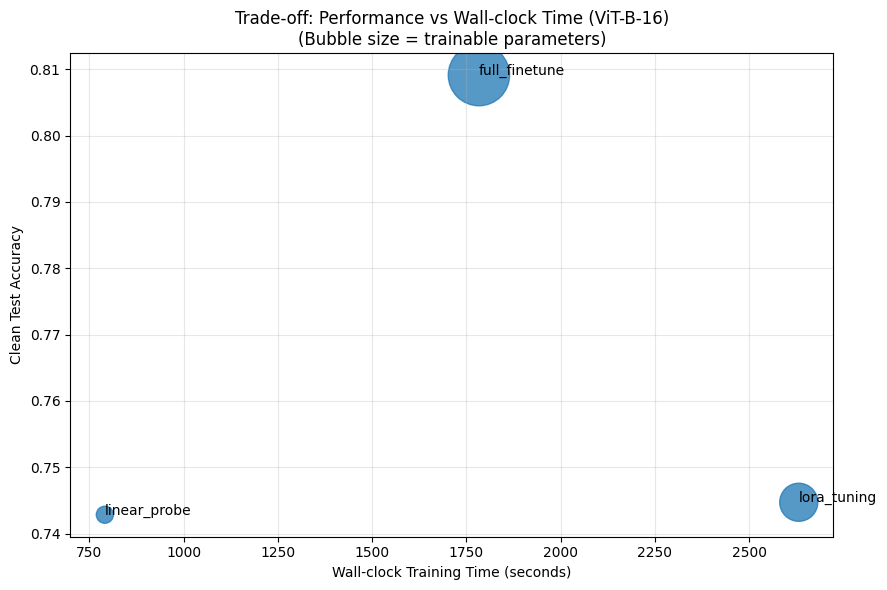

Saved: /content/tradeoff_perf_vs_time_vit.png


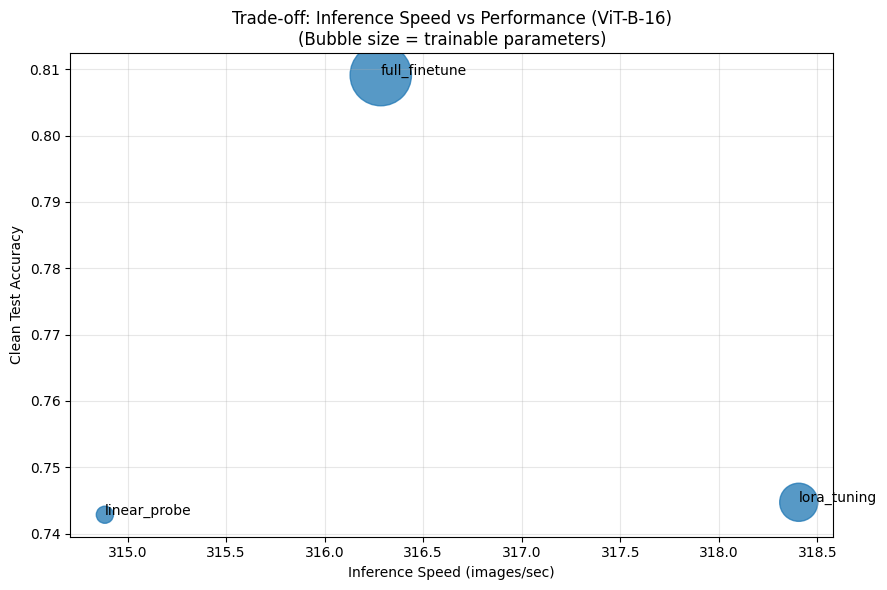

Saved: /content/tradeoff_inference_vs_perf_vit.png


In [21]:
# Required trade-off visualizations
if 'summary_df' not in globals():
    summary_df = pd.read_csv(PROJECT_DIR / 'vit_strategy_summary_all.csv')


def bubble_plot(df, x_col, y_col, x_label, y_label, title, out_name, x_log=False):
    size = (df['trainable_params'] / df['trainable_params'].max()) * 1800 + 150

    plt.figure(figsize=(9, 6))
    plt.scatter(df[x_col], df[y_col], s=size, alpha=0.75)

    for _, r in df.iterrows():
        plt.annotate(r['strategy'], (r[x_col], r[y_col]))

    if x_log:
        plt.xscale('log')

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title + '\n(Bubble size = trainable parameters)')
    plt.grid(alpha=0.3)
    plt.tight_layout()

    out_path = PROJECT_DIR / out_name
    plt.savefig(out_path, dpi=220)
    plt.show()
    print('Saved:', out_path)


bubble_plot(
    summary_df,
    x_col='train_seconds',
    y_col='clean_test_acc',
    x_label='Wall-clock Training Time (seconds)',
    y_label='Clean Test Accuracy',
    title='Trade-off: Performance vs Wall-clock Time (ViT-B-16)',
    out_name='tradeoff_perf_vs_time_vit.png',
)

bubble_plot(
    summary_df,
    x_col='inference_ips',
    y_col='clean_test_acc',
    x_label='Inference Speed (images/sec)',
    y_label='Clean Test Accuracy',
    title='Trade-off: Inference Speed vs Performance (ViT-B-16)',
    out_name='tradeoff_inference_vs_perf_vit.png',
)

if 'flops_g' in summary_df.columns and summary_df['flops_g'].notna().any():
    bubble_plot(
        summary_df,
        x_col='flops_g',
        y_col='clean_test_acc',
        x_label='Model FLOPs (GFLOPs)',
        y_label='Clean Test Accuracy',
        title='Trade-off: Performance vs FLOPs (ViT-B-16)',
        out_name='tradeoff_perf_vs_flops_vit.png',
    )


In [22]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 112.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=468152e4848f32c00e870ad4b565886b6215408bfb9856d23eb1560d6fa71edc
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


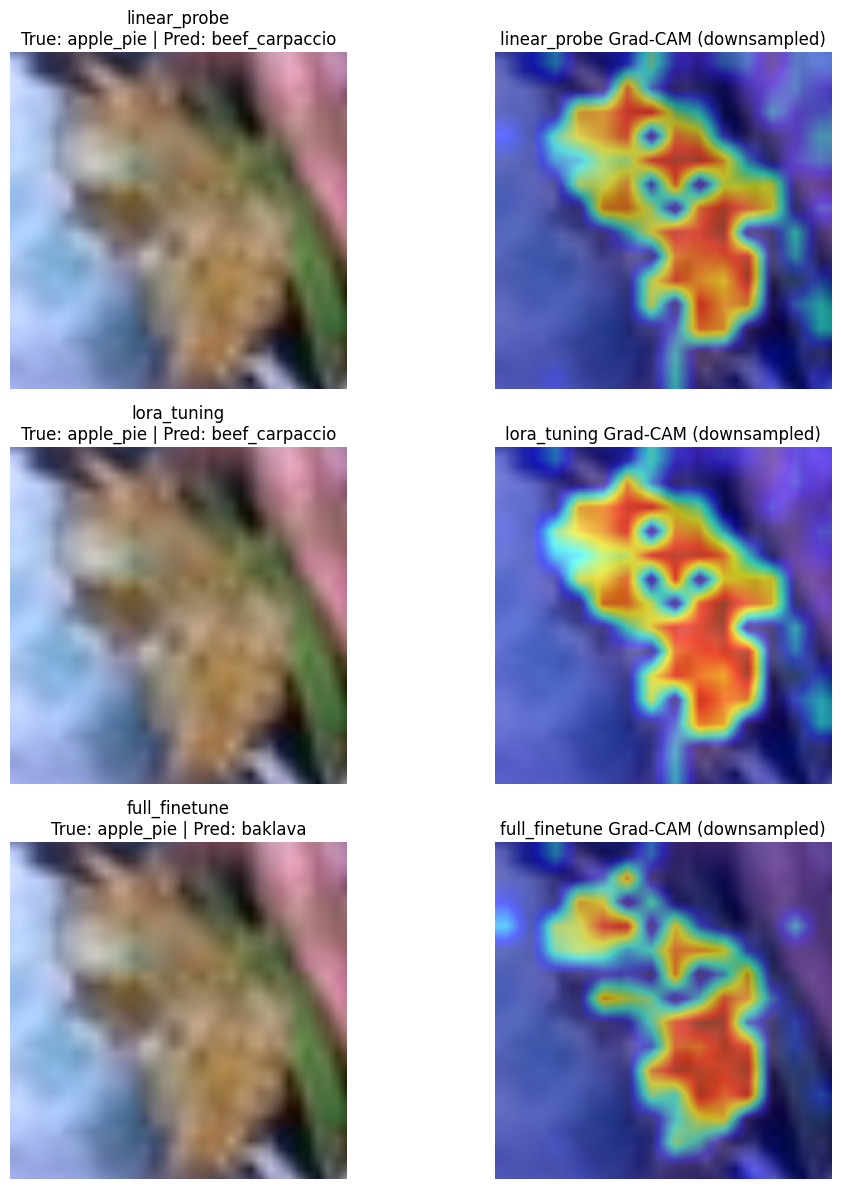

Saved: /content/gradcam_failure_comparison_vit.png


In [23]:
# Grad-CAM on selected failure sample from hardest variant
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except Exception as exc:
    raise RuntimeError('Install grad-cam first: pip install grad-cam') from exc

if 'hardest_variant' not in globals() or 'chosen_failure_idx' not in globals():
    raise ValueError('Run the evaluation cell first to set hardest_variant/chosen_failure_idx.')

if 'ACTIVE_STRATEGIES' not in globals() or not ACTIVE_STRATEGIES:
    raise ValueError('No evaluated strategies found. Run the evaluation cell first.')

ds = variant_datasets[hardest_variant]
img_t, y_true = ds[chosen_failure_idx]
x = img_t.unsqueeze(0).to(device)

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
img_np = img_t.permute(1, 2, 0).cpu().numpy()
img_np = np.clip(img_np * std + mean, 0, 1)


def vit_reshape_transform(tensor, h=14, w=14):
    tokens = tensor[:, 1:, :]
    tokens = tokens.reshape(tensor.size(0), h, w, tensor.size(2))
    return tokens.permute(0, 3, 1, 2)


def get_vit_cam_target_layer(model):
    base = model.model if hasattr(model, 'model') else model
    return [base.encoder.layers[-1].ln_1]


fig, axes = plt.subplots(len(ACTIVE_STRATEGIES), 2, figsize=(11, 4 * len(ACTIVE_STRATEGIES)))
if len(ACTIVE_STRATEGIES) == 1:
    axes = np.array([axes])

for i, strategy in enumerate(ACTIVE_STRATEGIES):
    model = load_strategy_model(strategy)
    with torch.no_grad():
        pred = int(model(x).argmax(1).item())

    target_layers = get_vit_cam_target_layer(model)
    with GradCAM(model=model, target_layers=target_layers, reshape_transform=vit_reshape_transform) as cam:
        grayscale_cam = cam(
            input_tensor=x,
            targets=[ClassifierOutputTarget(pred)],
            eigen_smooth=True,
        )[0]

    overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"{strategy}\nTrue: {idx_to_class[int(y_true)]} | Pred: {idx_to_class[pred]}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"{strategy} Grad-CAM ({hardest_variant})")
    axes[i, 1].axis('off')

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

plt.tight_layout()
out_path = PROJECT_DIR / 'gradcam_failure_comparison_vit.png'
plt.savefig(out_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


Variant set : downsampled
Variant path: /content/food101_transformed_test_variants/extracted/downsampled/apple_pie/1011328.jpg
Clean path  : /kaggle/input/food-101/food-101/food-101/images/apple_pie/1011328.jpg
Class       : apple_pie


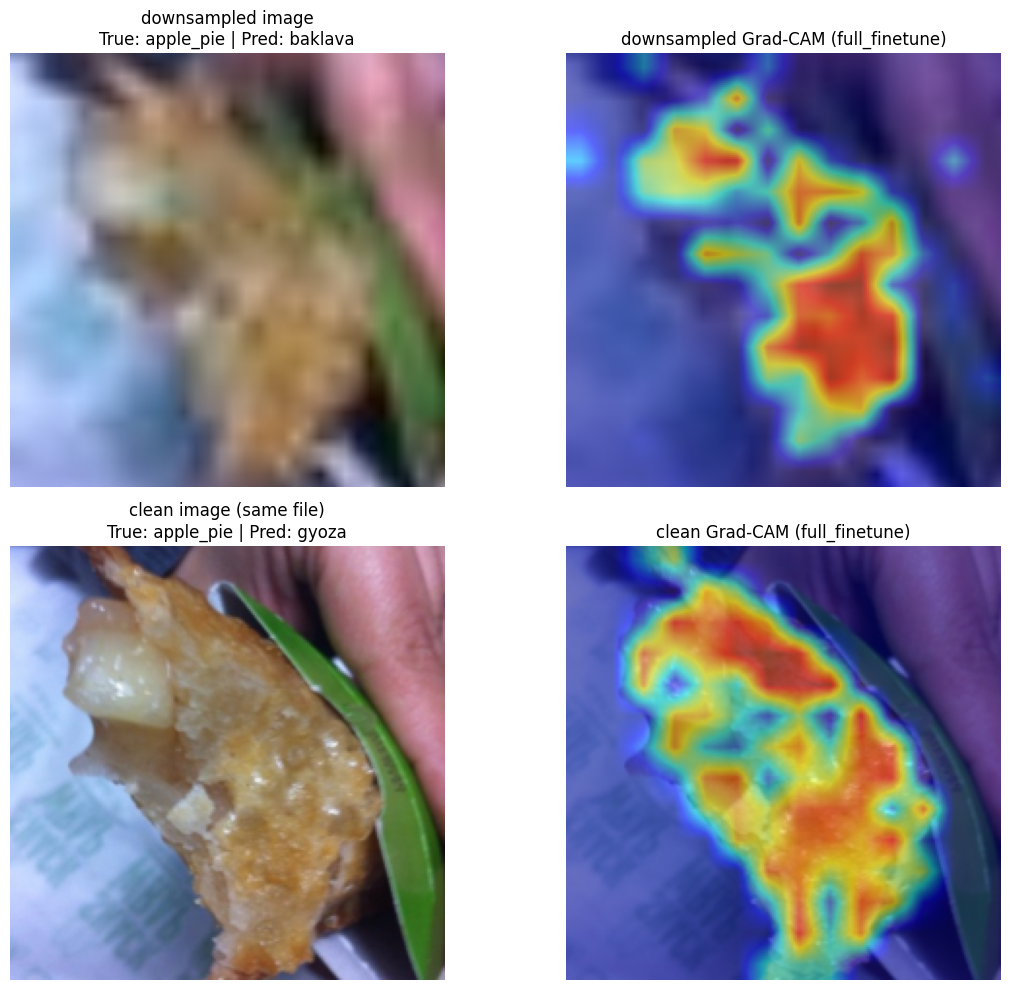

Saved: /content/gradcam_compare_apple_pie_full_finetune_downsampled_vs_clean_vit.png


In [25]:
# Grad-CAM comparison (ViT full_finetune): apple_pie downsampled vs clean
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except Exception as exc:
    raise RuntimeError('Install grad-cam first: pip install grad-cam') from exc

if 'variant_datasets' not in globals():
    raise ValueError('Run the variant evaluation cell first so variant_datasets exists.')

if 'load_strategy_model' not in globals() or 'idx_to_class' not in globals():
    raise ValueError('Run model/data setup cells first (load_strategy_model, idx_to_class).')

# Ensure full_finetune checkpoint path exists; fallback to Combined_Models if needed.
if 'strategy_ckpts' not in globals():
    raise ValueError('strategy_ckpts not found. Run core setup cells first.')

if 'full_finetune' not in strategy_ckpts or not Path(strategy_ckpts['full_finetune']).exists():
    fallback_ckpt = PROJECT_DIR.parent / 'Combined_Models' / 'full_model_vit.pth'
    if fallback_ckpt.exists():
        strategy_ckpts['full_finetune'] = fallback_ckpt
        print('Using fallback full_finetune checkpoint:', fallback_ckpt)
    else:
        msg = (
            'full_finetune checkpoint not found. Expected one of.\n'
            + f"- {strategy_ckpts.get('full_finetune')}\n"
            + f"- {fallback_ckpt}"
        )
        raise FileNotFoundError(msg)

# Prefer explicit downsampled dataset; fallback to hardest_variant if needed.
if 'downsampled' in variant_datasets:
    variant_name = 'downsampled'
else:
    if 'hardest_variant' not in globals():
        raise ValueError("Neither variant_datasets['downsampled'] nor hardest_variant is available.")
    variant_name = hardest_variant
    print(f"[WARN] 'downsampled' not found; using hardest_variant='{variant_name}'")

ds_var = variant_datasets[variant_name]

# Resolve apple_pie class index.
class_to_idx = {v: k for k, v in idx_to_class.items()}
if 'apple_pie' not in class_to_idx:
    raise ValueError("Class 'apple_pie' not found in class mapping.")
apple_idx = class_to_idx['apple_pie']

# Build model once.
model = load_strategy_model('full_finetune')
model.eval()

# Utility to read raw sample path from ImageFolderRemapped / Subset wrappers.
def get_variant_sample_path(ds, idx):
    if isinstance(ds, Subset):
        base_ds = ds.dataset
        base_idx = ds.indices[idx]
    else:
        base_ds = ds
        base_idx = idx
    # base_ds is ImageFolderRemapped, which wraps torchvision ImageFolder in .base
    path_str, _ = base_ds.base.samples[base_idx]
    return Path(path_str)

# Choose apple_pie sample from variant set.
# If chosen_failure_idx exists and is apple_pie, use it; otherwise pick first apple_pie.
chosen_idx = None
if 'chosen_failure_idx' in globals() and isinstance(chosen_failure_idx, (int, np.integer)):
    img_t_tmp, y_tmp = ds_var[int(chosen_failure_idx)]
    if int(y_tmp) == int(apple_idx):
        chosen_idx = int(chosen_failure_idx)

if chosen_idx is None:
    for i in range(len(ds_var)):
        _img_t, _y = ds_var[i]
        if int(_y) == int(apple_idx):
            chosen_idx = i
            break

if chosen_idx is None:
    raise RuntimeError(f"Could not find apple_pie in variant dataset '{variant_name}'.")

# Load selected variant tensor and locate matching clean image by filename.
var_img_t, var_y = ds_var[chosen_idx]
variant_path = get_variant_sample_path(ds_var, chosen_idx)
class_name = variant_path.parent.name
file_name = variant_path.name
clean_img_path = DATA_ROOT / 'images' / class_name / file_name
if not clean_img_path.exists():
    msg = (
        'Clean counterpart not found for variant sample.\n'
        + f'  variant: {variant_path}\n'
        + f'  expected clean: {clean_img_path}'
    )
    raise FileNotFoundError(msg)

# Prepare model inputs.
x_var = var_img_t.unsqueeze(0).to(device)
clean_pil = Image.open(clean_img_path).convert('RGB')
clean_img_t = transform(clean_pil)
x_clean = clean_img_t.unsqueeze(0).to(device)

with torch.no_grad():
    pred_var = int(model(x_var).argmax(1).item())
    pred_clean = int(model(x_clean).argmax(1).item())

# Denormalize for visualization.
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

var_np = var_img_t.permute(1, 2, 0).cpu().numpy()
var_np = np.clip(var_np * std + mean, 0, 1)

clean_np = clean_img_t.permute(1, 2, 0).cpu().numpy()
clean_np = np.clip(clean_np * std + mean, 0, 1)

# ViT Grad-CAM helpers (same approach as existing ViT Grad-CAM cell).
def vit_reshape_transform(tensor, h=14, w=14):
    tokens = tensor[:, 1:, :]
    tokens = tokens.reshape(tensor.size(0), h, w, tensor.size(2))
    return tokens.permute(0, 3, 1, 2)


def get_vit_cam_target_layer(model):
    base = model.model if hasattr(model, 'model') else model
    return [base.encoder.layers[-1].ln_1]


with GradCAM(model=model, target_layers=get_vit_cam_target_layer(model), reshape_transform=vit_reshape_transform) as cam:
    cam_var = cam(
        input_tensor=x_var,
        targets=[ClassifierOutputTarget(pred_var)],
        eigen_smooth=True,
    )[0]

    cam_clean = cam(
        input_tensor=x_clean,
        targets=[ClassifierOutputTarget(pred_clean)],
        eigen_smooth=True,
    )[0]

overlay_var = show_cam_on_image(var_np, cam_var, use_rgb=True)
overlay_clean = show_cam_on_image(clean_np, cam_clean, use_rgb=True)

true_cls = idx_to_class[int(var_y)]
print('Variant set :', variant_name)
print('Variant path:', variant_path)
print('Clean path  :', clean_img_path)
print('Class       :', true_cls)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(var_np)
axes[0, 0].set_title(f"{variant_name} image\nTrue: {true_cls} | Pred: {idx_to_class[pred_var]}")
axes[0, 0].axis('off')

axes[0, 1].imshow(overlay_var)
axes[0, 1].set_title(f"{variant_name} Grad-CAM (full_finetune)")
axes[0, 1].axis('off')

axes[1, 0].imshow(clean_np)
axes[1, 0].set_title(f"clean image (same file)\nTrue: {true_cls} | Pred: {idx_to_class[pred_clean]}")
axes[1, 0].axis('off')

axes[1, 1].imshow(overlay_clean)
axes[1, 1].set_title('clean Grad-CAM (full_finetune)')
axes[1, 1].axis('off')

plt.tight_layout()
out_path = PROJECT_DIR / f'gradcam_compare_{true_cls}_full_finetune_{variant_name}_vs_clean_vit.png'
plt.savefig(out_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', out_path)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
if torch.backends.mps.is_available() and hasattr(torch, 'mps'):
    torch.mps.empty_cache()
